# Geração de Relatórios em PDF com `fpdf2`

---

## Introdução
O objetivo deste notebook é aprender a utilizar a biblioteca `fpdf2` para gerar relatórios em PDF de forma automatizada, simulando um cenário real de negócios onde precisamos enviar um relatório de vendas para a diretoria.

Em um cenário simulado, você é um analista de dados e precisa gerar um relatório diário de vendas. O relatório deve conter um cabeçalho padrão, um texto introdutório, uma tabela de desempenho por região com cores indicativas (verde para meta atingida, vermelho para não atingida), um gráfico e um rodapé com numeração de páginas.


### Conteúdo
1. Instalação e Importação das Bibliotecas

---

## 1. Instalação e Importação das Bibliotecas
Para este projeto, usaremos o `fpdf2` para gerar o PDF, `pandas` para simular e manipular os dados de vendas, e `matplotlib` para gerar um gráfico rápido que será inserido no relatório.

*Execute a célula abaixo para instalar as bibliotecas (caso ainda não estejam instaladas).*

In [1]:
!pip install fpdf2 pandas matplotlib -q

In [16]:
import sys
import os
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
from fpdf import FPDF
from fpdf.enums import XPos, YPos

print('- BIBLIOTECAS CARREGADAS -')
print(f'Python versão: {sys.version}')

- BIBLIOTECAS CARREGADAS -
Python versão: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


---

## 2. Simulando os Dados de Vendas e Gerando um Gráfico
Em uma situação real, você leria dados de um banco de dados (SQL) ou de um arquivo Excel/CSV. Aqui, vamos criar um DataFrame com o Pandas para representar nossas vendas e gerar um gráfico de barras para anexar ao PDF.

### 2.1 Criando dados simulados

In [4]:
dados_vendas = {
    "Regiao": ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"],
    "Vendas": [150000, 85000, 110000, 45000, 30000],
    "Meta": [120000, 90000, 100000, 50000, 40000]
}
df = pd.DataFrame(dados_vendas)
df

,Regiao,Vendas,Meta
0,Sudeste,150000,120000
1,Sul,85000,90000
2,Nordeste,110000,100000
3,Centro-Oeste,45000,50000
4,Norte,30000,40000


A seguir vamos adicionar status para a Meta no relatório.

In [5]:
df['Status'] = df.apply(lambda row: 'Atingida' if row['Vendas'] >= row['Meta'] else 'Abaixo', axis=1)
df

,Regiao,Vendas,Meta,Status
0,Sudeste,150000,120000,Atingida
1,Sul,85000,90000,Abaixo
2,Nordeste,110000,100000,Atingida
3,Centro-Oeste,45000,50000,Abaixo
4,Norte,30000,40000,Abaixo


### 2.2 Gerando o Gráfico com Matplotlib

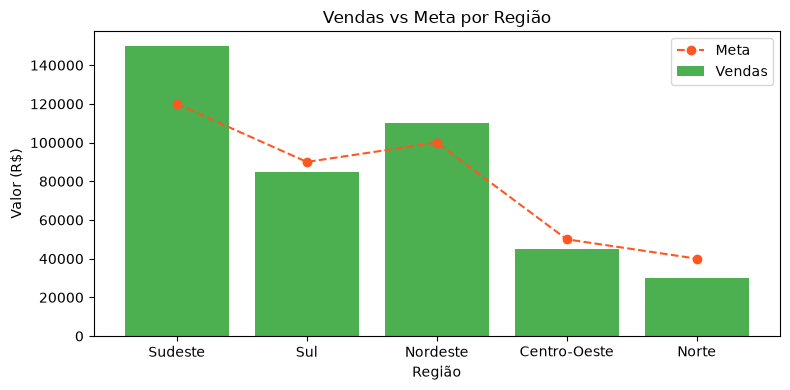

In [9]:
plt.figure(figsize=(8, 4))

plt.bar(df['Regiao'], df['Vendas'], color='#4CAF50', label='Vendas')
plt.plot(df['Regiao'], df['Meta'], color='#FF5722', marker='o', linestyle='--', label='Meta')

plt.title('Vendas vs Meta por Região')
plt.xlabel('Região')
plt.ylabel('Valor (R$)')
plt.legend()

plt.tight_layout()

#persistir grafico para relatorio
caminho_grafico = "grafico_vendas.png"
plt.savefig(caminho_grafico)

plt.show()

---

## 3. Entendendo os Conceitos Básicos do `fpdf2`
O `fpdf2` funciona como uma tela onde vamos "desenhando" os elementos. Os principais métodos são:
*   `cell()`: Cria uma "caixa" de texto. Útil para títulos e tabelas. Não quebra linha automaticamente.
*   `multi_cell()`: Cria uma caixa de texto que quebra a linha automaticamente quando atinge a borda. Ideal para parágrafos.
*   `set_font(family, style, size)`: Define a fonte atual (ex: `Helvetica`, `B` para negrito, `12` para tamanho).
*   `ln(h)`: Adiciona uma quebra de linha (espaço vertical).

A seguir, é hora de criar uma classe personalizada. Em POO (Programação Orientada a Objetos), sobrescreveremos os métodos `header()` e `footer()` para que o cabeçalho e rodapé se repitam em todas as páginas automaticamente.

In [17]:
class RelatorioVendasPDF(FPDF):
    
    def header(self):
        # Configuração da fonte do cabeçalho
        self.set_font("Helvetica", "B", 15)
        
        # Título do relatório
        self.cell(
            0, 10, "Relatório de Vendas Mensal", 
            border=False, 
            new_x=XPos.LMARGIN, new_y=YPos.NEXT, 
            align="C"
        )
        
        # Adicionando a data atual no canto direito
        self.set_font("Helvetica", "I", 8)
        self.cell(
            0, 5, f"Data de Emissão: {self.data_emissao}", 
            new_x=XPos.LMARGIN, new_y=YPos.NEXT, 
            align="R"
        )
        
        # Espaço antes da linha
        self.ln(2)
        
        # Linha divisória :: Usa get_y() para se adaptar a qualquer situação
        y_atual = self.get_y()
        self.line(10, y_atual, 200, y_atual)
        
        # Espaço após o cabeçalho
        self.ln(5)

    def footer(self):
        # Posiciona o cursor a 1.5 cm do final da página
        self.set_y(-15)
        # Fonte itálica 8
        self.set_font("Helvetica", "I", 8)
        # Número da página 
        self.cell(
            0, 10, f"Página {self.page_no()}/{{nb}}", 
            new_x=XPos.LMARGIN, new_y=YPos.NEXT,
            align="C"
        )

---

## 4. Construção do Relatório Passo a Passo
Agora vamos instanciar nosso PDF e adicionar os elementos na tela, um por um, para entender o fluxo de construção do documento.

In [21]:
hoje = date.today()
data_br = hoje.strftime("%d/%m/%Y")
nome_arquivo = "relatorio_passo_a_passo.pdf"

In [29]:
# Função auxiliar para deixar o código mais limpo 
def formatar_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [30]:
# 1. Instanciamos o PDF
pdf = RelatorioVendasPDF(orientation="P", unit="mm", format="A4")
pdf.alias_nb_pages() # Habilita a contagem total de páginas {nb}
pdf.data_emissao = data_br # Passando a data para o cabeçalho
pdf.add_page() # Adiciona a primeira página :: chama o método header automaticamente

# 2. Adicionando um Parágrafo Introdutório
pdf.set_font("Helvetica", size=11)
texto_intro = ("Este relatório apresenta o resumo das vendas realizadas no último mês. "
               "Os dados foram extraídos do sistema de gestão ERP e processados para análise "
               "de desempenho por região. O gráfico e a tabela a seguir detalham os resultados.")

pdf.multi_cell(0, 6, texto_intro) # O multi_cell já pula de linha automaticamente no final
pdf.ln(5) # 5mm

# 3. Título da Seção da Tabela
pdf.set_font("Helvetica", "B", 12)
pdf.set_text_color(33, 37, 41) # Cor cinza escuro
pdf.cell(0, 10, "Desempenho por Região:", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(2)

# 4. Cabeçalho da Tabela
pdf.set_font("Helvetica", "B", 10)
pdf.set_fill_color(220, 220, 220) # Cinza claro para fundo
pdf.set_text_color(0, 0, 0) # Texto preto

# Larguras das colunas (em mm)
largura_regiao = 50
largura_vendas = 40
largura_meta = 40
largura_status = 60

pdf.cell(largura_regiao, 8, "Região", border=1, align="C", fill=True)
pdf.cell(largura_vendas, 8, "Vendas (R$)", border=1, align="C", fill=True)
pdf.cell(largura_meta, 8, "Meta (R$)", border=1, align="C", fill=True)
# Última célula do cabeçalho recebe a quebra de linha
pdf.cell(largura_status, 8, "Status", border=1, align="C", fill=True, new_x=XPos.LMARGIN, new_y=YPos.NEXT)

# 5. Linhas de Dados da Tabela
pdf.set_font("Helvetica", size=10)

# Iterando sobre o DataFrame do Pandas
for index, row in df.iterrows():
    # Formatação condicional para a cor do texto do Status
    if row['Status'] == 'Atingida':
        pdf.set_text_color(0, 128, 0) # Verde
    else:
        pdf.set_text_color(255, 0, 0) # Vermelho
        
    # Inserindo os dados
    pdf.cell(largura_regiao, 8, row['Regiao'], border=1, align="L")
    
    # Formatando os valores numéricos para moeda brasileira
    pdf.set_text_color(0, 0, 0) # Voltando para preto
    # IMPORTANTE: align="R" exige new_x=XPos.RIGHT para não sobrepor a próxima coluna
    pdf.cell(largura_vendas, 8, formatar_moeda(row['Vendas']), border=1, align="R", new_x=XPos.RIGHT)
    pdf.cell(largura_meta, 8, formatar_moeda(row['Meta']), border=1, align="R", new_x=XPos.RIGHT)
    
    # Voltando a cor do status para imprimir a célula
    if row['Status'] == 'Atingida':
        pdf.set_text_color(0, 128, 0)
    else:
        pdf.set_text_color(255, 0, 0)
    # Última célula da linha: volta para a esquerda e pula linha
    pdf.cell(largura_status, 8, row['Status'], border=1, align="C", new_x=XPos.LMARGIN, new_y=YPos.NEXT)

# Resetando a cor do texto
pdf.set_text_color(0, 0, 0)
pdf.ln(10)

# 6. Inserindo o Gráfico
pdf.set_font("Helvetica", "B", 12)
pdf.cell(0, 10, "Análise Gráfica:", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
pdf.ln(2)

# x define a posição horizontal (centralizamos calculando a margem)
# w define a largura da imagem
pos_x_grafico = (210 - 150) / 2 # 210mm é a largura do A4
pdf.image(caminho_grafico, x=pos_x_grafico, w=150)

# Salvando o arquivo
pdf.output(nome_arquivo)
print(f"Arquivo '{nome_arquivo}' gerado com sucesso!")

Arquivo 'relatorio_passo_a_passo.pdf' gerado com sucesso!


---

## 5. Automação para Situação Real
No dia a dia, não construímos o PDF célula por célula toda vez. Nós encapsulamos essa lógica dentro de uma função que recebe os dados e gera o arquivo pronto para envio. 

Abaixo, criamos uma função `gerar_relatorio_vendas` que automatiza todo o processo acima.

In [31]:
import datetime
from fpdf.enums import XPos, YPos

def gerar_relatorio_vendas(df, caminho_da_imagem, arquivo_saida="relatorio_automatico.pdf"):
    """
    Função que automatiza a geração do relatório de vendas em PDF.
    """
    print("Iniciando a geração do relatório...")
    
    # Instancia a classe
    pdf = RelatorioVendasPDF()
    pdf.alias_nb_pages()
    
    # Passa a data atual dinamicamente para o cabeçalho
    pdf.data_emissao = datetime.datetime.now().strftime("%d/%m/%Y")
    pdf.add_page()
    
    # --- Texto Introdutório ---
    pdf.set_font("Helvetica", size=11)
    pdf.multi_cell(0, 6, "Relatório automático gerado pelo sistema. Resumo das vendas da empresa no último período.")
    pdf.ln(5)
    
    # --- Tabela ---
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 10, "Desempenho por Região:", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.ln(2)
    
    # Cabeçalho da tabela
    pdf.set_font("Helvetica", "B", 10)
    pdf.set_fill_color(220, 220, 220)
    pdf.cell(50, 8, "Região", border=1, align="C", fill=True)
    pdf.cell(40, 8, "Vendas (R$)", border=1, align="C", fill=True)
    pdf.cell(40, 8, "Meta (R$)", border=1, align="C", fill=True)
    pdf.cell(60, 8, "Status", border=1, align="C", fill=True, new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    
    # Dados
    pdf.set_font("Helvetica", size=10)
    for index, row in df.iterrows():
        # Lógica de cor
        cor_texto = (0, 128, 0) if row['Status'] == 'Atingida' else (255, 0, 0)
        
        pdf.cell(50, 8, row['Regiao'], border=1, align="L")
        
        pdf.set_text_color(0, 0, 0)
        vendas_formatado = f"R$ {row['Vendas']:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        meta_formatado = f"R$ {row['Meta']:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        
        pdf.cell(40, 8, vendas_formatado, border=1, align="R", new_x=XPos.RIGHT)
        pdf.cell(40, 8, meta_formatado, border=1, align="R", new_x=XPos.RIGHT)
        
        pdf.set_text_color(*cor_texto)
        pdf.cell(60, 8, row['Status'], border=1, align="C", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        
    pdf.set_text_color(0, 0, 0)
    pdf.ln(10)
    
    # --- Imagem ---
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 10, "Análise Gráfica:", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
    pdf.ln(2)
    pos_x = (210 - 150) / 2
    pdf.image(caminho_da_imagem, x=pos_x, w=150)
    
    # --- Output ---
    pdf.output(arquivo_saida)
    print(f"✅ Relatório gerado com sucesso: {arquivo_saida}")

In [32]:
# Executando a função de automação
gerar_relatorio_vendas(df, caminho_grafico, "Relatorio_Vendas_Final.pdf")

# Limpeza do arquivo temporário do gráfico 
os.remove(caminho_grafico)

Iniciando a geração do relatório...
✅ Relatório gerado com sucesso: Relatorio_Vendas_Final.pdf


---

## 6. Conclusão e Considerações Finais
